# Shlukování monitorovacích lokalit sítě na základě hustoty pomocí PROC MODECLUS


## Shrnutí

Distribuční energetická společnost používá PROC MODECLUS k nalezení
neparametrických shluků založených na hustotě mezi svými monitorovacími
lokalitami sítě (rozvodny a senzory vývodů) pouze na základě jejich
mapových souřadnic. MODECLUS odhaduje povrch hustoty nad lokalitami a
shluky považuje za oblasti s vysokou hustotou oddělené mezerami s
nízkou hustotou. Spuštění na 90 simulovaných lokalitách s poloměrem
uniformního jádra 3 km obnoví tři husté servisní oblasti, které jsme
vestavěli do dat, jako tři největší shluky (24, 24 a 21 lokalit),
zatímco rozptýlené venkovské lokality spadají do řídkých oblastí a
rozpadají se na vlastní jedno- a dvoulokalitní mikroshluky. Tato
množina izolovaných lokalit je provozním výstupem: seznam kandidátů
vzdálených aktiv pro tým kapitálového plánování.


## Zdroje dat

| Dataset | Řádky | Popis |
|---------|------|-------------|
| `grid_sites` | 90 | Syntetické monitorovací lokality distribuční sítě generované přímo pomocí `call streaminit(70531)` a `rand()`. Tři husté servisní oblasti (Centrum, Předměstí, Průmysl) vygenerované z bivariátních normálních rozdělení kolem odlišných mapových center, plus 22 rozptýlených venkovských lokalit vygenerovaných rovnoměrně po celém území. |

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `site_id` | Num | Jedinečný identifikátor monitorovací lokality (1-90). |
| `region` | Char | Plánovací štítek zaznamenávající, jak byla každá lokalita vygenerována (Centrum, Předměstí, Průmysl, Venkov); vyloučen ze shlukování. |
| `x_km`, `y_km` | Num | Poloha lokality v kilometrech na plánovací síti společnosti; shlukovací proměnné. |
| `peak_load_mw` | Num | Pozorované roční špičkové zatížení (MW) v lokalitě; přenášeno pro pozdější interpretaci. |


# Shlukování monitorovacích lokalit sítě na základě hustoty

Regionální distribuční energetická společnost provozuje síť
**monitorovacích lokalit** -- rozvoden a senzorů vývodů -- rozmístěných
po celém svém servisním území. Plánovači chtějí tyto lokality seskupit
do přirozených **servisních oblastí** čistě na základě geografie, bez
předchozího určení počtu skupin, a identifikovat **izolovaná venkovská
aktiva**, která nepatří do žádné husté oblasti.

`PROC MODECLUS` se k tomu skvěle hodí: provádí *neparametrické
shlukování založené na hustotě*. Odhaduje funkci hustoty nad
lokalitami a poté shluky považuje za oblasti s vysokou hustotou
lokalit oddělené mezerami s nízkou hustotou. Řídké odlehlé hodnoty
skončí ve vlastních drobných shlucích, místo aby byly pohlceny
oblastí -- přesně to chování, které chceme pro označení vzdálených
lokalit.

Tento sešit:
1. Vygeneruje realistickou syntetickou síť 90 lokalit.
2. Odhadne hustotu lokalit pomocí **uniformního jádra** a proskenuje
   vyhlazovací poloměr `R=`, aby potvrdil, že nalezené oblasti jsou
   stabilní.
3. Zafixuje pracovní poloměr, zapíše dataset `OUT=` s hustotou a
   označením shluku pro každou lokalitu a výsledek zmapuje.


## Krok 1 -- Vygenerování syntetické sítě monitorovacích lokalit

Simulujeme 90 lokalit. Tři husté **servisní oblasti** jsou vygenerovány
z bivariátních normálních rozdělení kolem odlišných mapových center
(Centrum poblíž (12, 30), Předměstí poblíž (30, 15), Průmysl poblíž
(20, 42)), což dává kompaktní shluky s vysokou hustotou o 24, 24 a 20
lokalitách. Čtvrtá skupina 22 **venkovských** lokalit je vygenerována
rovnoměrně po celém území, čímž vznikají řídké, rozptýlené lokality,
které by společnost považovala za izolované.

Štítek `region` zaznamenává, jak byla každá lokalita vygenerována;
záměrně jej **vyloučíme** ze shlukování, aby MODECLUS znovu odhalil
strukturu pouze ze souřadnic. `peak_load_mw` je přenášeno pro pozdější
interpretaci.


In [1]:
data grid_sites;
   CALL streaminit(70531);
   DÉLKA region $ 20;

   /* Hustá městská servisní oblast */
   OPAKUJ site_id = 1 TO 24;
      region = 'Centrum';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      VÝSTUP;
   KONEC;

   /* Předměstská oblast */
   OPAKUJ site_id = 25 TO 48;
      region = 'Předměstí';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      VÝSTUP;
   KONEC;

   /* Průmyslová oblast (vyšší špičkové zatížení) */
   OPAKUJ site_id = 49 TO 68;
      region = 'Průmysl';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      VÝSTUP;
   KONEC;

   /* Rozptýlené venkovské lokality (řídké, nízké zatížení) */
   OPAKUJ site_id = 69 TO 90;
      region = 'Venkov';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      VÝSTUP;
   KONEC;
SPUSTIT;

NÁZEV 'Syntetické monitorovací lokality sítě';
PROC MEANS data=grid_sites n mean std MIN MAX maxdec=2;
   TŘÍDA region;
   PROMĚNNÁ x_km y_km peak_load_mw;
   ŠTÍTEK region="Oblast" x_km="X (km)" y_km="Y (km)" peak_load_mw="Špičkové zatížení (MW)";
SPUSTIT;


                                         Syntetické monitorovací lokality sítě                                          

                                                  The MEANS Procedure

                                            Analysis Variable : x_km X (km)

        Oblast                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        Centrum                  24          12.07           1.34           8.65          14.42
        Průmysl                  20          20.36           0.96          18.52          21.53
        Předměstí                24          29.96           1.73          26.51          33.60
        Venkov                   22          29.79          10.62          11.06          47.45
        ---------------------------------------------------------------------------------------

                                            Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Syntetické monitorovací lokality sítě.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Průměry potvrzují tři úzké oblasti a jednu difuzní skupinu. Tři husté
oblasti mají malé směrodatné odchylky souřadnic (zhruba 1-1,7 km na
každé ose) kolem dobře oddělených center, zatímco venkovská skupina se
rozprostírá po celé síti (směrodatné odchylky nad 10 km na obou osách).
Špičkové zatížení také odlišuje oblasti -- lokality Průmysl mají
průměr kolem 6 MW, Centrum kolem 4,6 MW, Předměstí kolem 2,7 MW a
venkovské lokality kolem 1,5 MW -- což je užitečný kontext, jakmile
máme geografické shluky k dispozici.


## Krok 2 -- Shlukování hustoty s uniformním jádrem a skenování poloměru

Odhad hustoty s uniformním jádrem používá **poloměr `R=`**: každá
lokalita ve vzdálenosti `R` kilometrů přispívá k lokální hustotě dané
lokality. Malé `R` dává kolísavou hustotu, která fragmentuje území;
velké `R` přehlazuje a slučuje oblasti. Zkušený analytik nikdy nevěří
jediné hodnotě -- proskenuje rozsah poloměrů a hledá počet shluků,
který je **stabilní**, kdy husté oblasti přetrvávají a mění se jen
počet rozptýlených samostatných lokalit.

Zde `M=1` vybírá metodu shlukování 1 (standardní neparametrická
metoda) a v jednom volání požadujeme poloměry `R=2.5 to 4 by 0.5`.
MODECLUS provede analýzu pro každý poloměr zvlášť a pro každý uvede
počet shluků. `SHORT` potlačuje podrobné statistiky za jednotlivé
shluky.


In [2]:
NÁZEV 'Shlukování hustoty s uniformním jádrem pro lokality sítě';
title2 'Skenování poloměru R = 2,5 až 4,0 km';

PROC modeclus data=grid_sites m=1 r=2.5 TO 4 PODLE 0.5 short;
   PROMĚNNÁ x_km y_km;
   id site_id;
   ŠTÍTEK x_km="X (km)" y_km="Y (km)" site_id="ID lokality";
SPUSTIT;


                                Shlukování hustoty s uniformním jádrem pro lokality sítě                                
                                          Skenování poloměru R = 2,5 až 4,0 km                                          


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Shlukování hustoty s uniformním jádrem pro lokality sítě.
NOTE: Option TITLE2 changed to Skenování poloměru R = 2,5 až 4,0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Počet shluků se během skenování mění jen mírně -- 23 shluků při
`R=2,5`, 22 při `R=3,0`, 19 při `R=3,5` a 18 při `R=4,0`. Vysoké
hrubé počty pocházejí z rozptýlených venkovských lokalit: každá
izolovaná lokalita sedí ve vlastním řídkém okolí a tvoří jednolokalitní
shluk, takže většina z 18-23 "shluků" jsou samostatné lokality. Co
zůstává v pozadí konstantní, je struktura, na které záleží -- tři husté
oblasti zůstávají třemi velkými, dobře oddělenými shluky při každém
poloměru. Jak se `R` rozšiřuje, několik rozptýlených samostatných
lokalit se spojí se sousedem nebo blízkou oblastí, což je důvod, proč
celkový počet pomalu klesá, místo aby se prudce měnil. Tato stabilita
je signálem, že řešení se třemi oblastmi je skutečné a není artefaktem
jedné šířky pásma.


## Krok 3 -- Finální shlukové řešení pro mapování

Jelikož jsme viděli, že tři oblasti jsou stabilní napříč skenováním,
zafixujeme jediný pracovní poloměr (`R=3` km) a požádáme o volbu
**ALL** pro úplné zobrazení za jednotlivé shluky, plus **OUT=** pro
zápis původních souřadnic spolu s odhadem `DENSITY` a přiřazením
`CLUSTER`, abychom mohli výsledek zmapovat. Shluky jsou číslovány
sestupně podle modální hustoty, takže nejhustší oblasti jsou shluky 1,
2 a 3 a řídké lokality dostávají vyšší čísla.


In [3]:
NÁZEV 'Finální řešení shlukování založené na hustotě';
title2 'Uniformní jádro, R = 3 km';

PROC modeclus data=grid_sites m=1 r=3 out=join_out ALL;
   PROMĚNNÁ x_km y_km;
   id site_id;
   ŠTÍTEK x_km="X (km)" y_km="Y (km)" site_id="ID lokality";
SPUSTIT;


                                     Finální řešení shlukování založené na hustotě                                      
                                               Uniformní jádro, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: X (km) Y (km)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
  


NOTE: Option TITLE changed to Finální řešení shlukování založené na hustotě.
NOTE: Option TITLE2 changed to Uniformní jádro, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Souhrn shluků strukturu jasně ukazuje. Řešení `R=3` vrací **22
shluků**, ale jsou ostře odstupňovány podle hustoty:

- **Shluk 1** -- 24 lokalit, modální hustota asi 0,0090 (oblast
  Centrum).
- **Shluk 2** -- 24 lokalit, modální hustota asi 0,0079 (oblast
  Předměstí).
- **Shluk 3** -- 21 lokalit, modální hustota asi 0,0079 (oblast
  Průmysl; zachytává jednu venkovskou lokalitu, která náhodou spadla
  na její okraj).
- **Shluky 4-22** -- skupina tří lokalit a osmnáct jednolokalitních
  shluků, vše při modální hustotě asi 0,0004, zhruba dvacetkrát řidší
  než oblasti.

Tři husté oblasti tvoří 69 z 90 lokalit; zbývajících 21 lokalit jsou
rozptýlená venkovská aktiva, z nichž každé sedí samo nebo téměř samo v
okolí s nízkou hustotou. Hranici mezi servisní oblastí a izolovanou
lokalitou určuje hustota, nikoli předem daný počet shluků.


## Krok 4 -- Zmapování shluků

Označíme každou lokalitu podle toho, zda spadla do jedné ze tří
hustých oblastí (`cluster <= 3`) nebo do řídkého mikroshluku, a poté
vykreslíme každou lokalitu na jejích mapových souřadnicích obarvenou
podle tohoto stavu. Toto je pohled plánovače: husté oblasti spravovat
jako servisní území a izolované lokality označit pro samostatné
zacházení.


                                      Nalezené servisní oblasti a izolovaná místa                                       
                                    Shlukování hustoty s uniformním jádrem, R = 3 km                                    




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Nalezené servisní oblasti a izolovaná místa.
NOTE: Option TITLE2 changed to Shlukování hustoty s uniformním jádrem, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


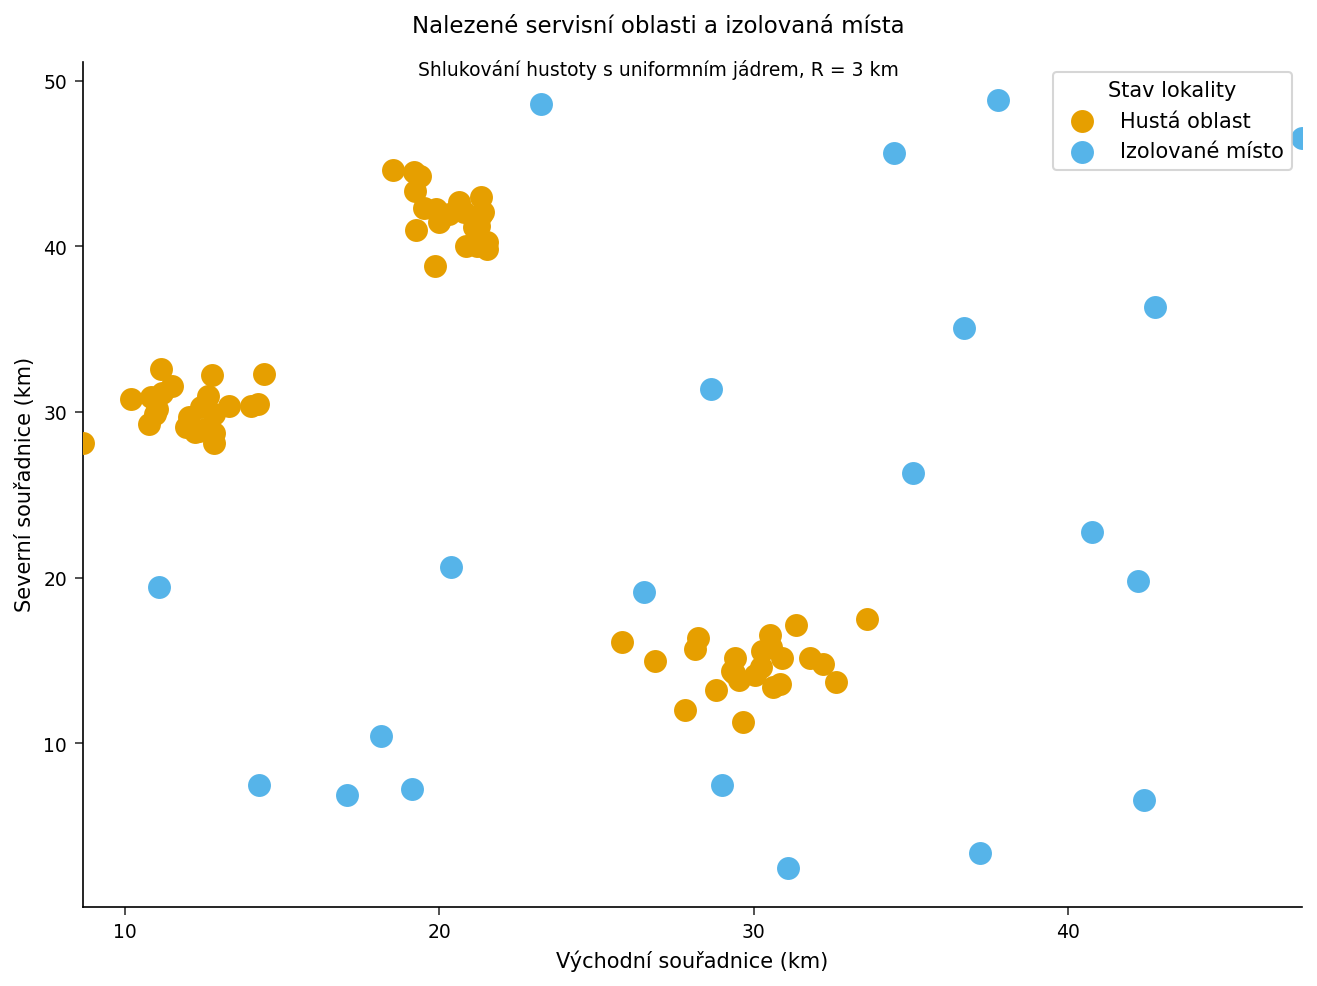

In [4]:
data mapped;
   NASTAVIT join_out;
   DÉLKA status $ 30;
   KDYŽ CLUSTER <= 3 PAK status = 'Hustá oblast';
   JINAK status = 'Izolované místo';
SPUSTIT;

NÁZEV 'Nalezené servisní oblasti a izolovaná místa';
title2 'Shlukování hustoty s uniformním jádrem, R = 3 km';
PROC SGPLOT data=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS ŠTÍTEK='Východní souřadnice (km)';
   YAXIS ŠTÍTEK='Severní souřadnice (km)';
   keylegend / NÁZEV='Stav lokality';
SPUSTIT;

NÁZEV;


## Interpretace výsledků

**Co MODECLUS zjistil.** Řízen pouze proměnnými `(x_km, y_km)`,
postup obnoví tři husté servisní oblasti, které jsme vestavěli do dat
-- shluky Centrum, Předměstí a Průmysl -- jako tři největší, nejhustší
shluky (24, 24 a 21 lokalit). Rozptýlené venkovské lokality,
vygenerované rovnoměrně po celém území, spadají do řídkých oblastí a
rozpadají se na vlastní jedno- a dvoulokalitní shluky, místo aby byly
pohlceny oblastí. Na mapě jsou to body oddělené od tří kompaktních
shluků. Tato izolovaná množina je provozním výstupem: seznam kandidátů
vzdálených aktiv pro tým kapitálového plánování.

**Proč záleží na vyhlazovacím skenování.** Žádné jediné `R` není
autoritativní pro neparametrické shlukování založené na hustotě.
Skenování `R=2.5 to 4 by 0.5` nám umožňuje potvrdit, že oblasti jsou
*stabilní* napříč úrovněmi vyhlazení, a ne artefaktem jedné šířky
pásma. Během skenování se počet shluků mění jen z 23 na 18 a celá
změna se odehrává v počtu rozptýlených samostatných lokalit -- tři
husté oblasti přetrvávají po celou dobu. Tam, kde struktura takto
zůstala stabilní, máme obhajitelné řešení; kdyby se počet prudce
měnil, struktura by byla křehká a neměla by řídit investiční
rozhodnutí.

**Hustota odstupňuje výsledek.** Protože shluky jsou číslovány sestupně
podle modální hustoty, rozdíl mezi oblastmi a izolovanými lokalitami je
kvantitativní, nikoli libovolný: tři oblasti leží poblíž modální
hustoty 0,008-0,009, zatímco každá izolovaná lokalita leží poblíž
0,0004, zhruba dvacetkrát řidší. Plánovač může nastavit hranici
hustoty a přečíst izolovaná aktiva přímo ze sloupců `CLUSTER` a
`DENSITY` datasetu `join_out`.

**Praktické využití.** Dataset `join_out` dává každé lokalitě hustotu
a označení shluku, které mohou nastartovat navazující práci -- určení
velikosti čet a náhradních dílů podle servisní oblasti, plánování
kontrolních okruhů nebo prioritizaci zpevňování sítě v hustém
průmyslovém shluku (nejvyšší `peak_load_mw`, asi 6 MW), zatímco
izolované venkovské lokality se naplánují na samostatnou, méně
častou údržbu.

*Poznámka k syntetickým datům:* souřadnice a zatížení jsou simulovány
s pevným semínkem (`call streaminit(70531)`), takže je sešit plně
reprodukovatelný offline; u reálných dat společnosti byste dosadili
zaměřené souřadnice lokalit a měřená špičková zatížení. Přesné počty
shluků závisí na náhodném tahu a zvoleném poloměru.
